In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize, Bounds
from GASModels.dynamics import Dynamics
from GASModels.distributions.gamma_log_link import GammaLogLinkDistribution
from GASModels.distributions.gb2_log_link import GB2LogLinkDistribution
from GASModels.distributions.za_gb2_log_link import ZAGB2LogLinkDistribution

In [2]:
xls = pd.read_csv('data/precipitation.csv')

In [3]:
# Create dynamics object
dynamics = Dynamics(
    distribution=ZAGB2LogLinkDistribution(),
    n=len(xls['precipitation'][0:730]),
    trend=None,
    seasonality=None,
    harmonics=20,
    period=365.25,
    time_varying_indices=[0],
    fixed_params_indices=[1],
    args=[0.05, 0.02]
)


In [15]:
def objective_function(params, y, distribution):
    """
    Proper objective function: negative log-likelihood
    """
    # Unpack parameters - ZAGB2 needs 6 parameters
    delta_0, delta_1, gamma, xi, zeta = params
    delta_0 = delta_0 / 100
    delta_1 = delta_1 / 100
    gamma = gamma / 100
    xi = xi / 100
    zeta = zeta / 100
    phi = np.ones(len(y))
    
    total_loglik = 0.0
    
    for t in range(len(y)):
        try:
            if phi[t] <= 0 or gamma <= 0 or xi <= 0 or zeta <= 0:
                return np.inf
            if np.exp(zeta) <= np.exp(gamma):
                return np.inf
            loglik = distribution.logpdf(
                y[t],
                delta_0=delta_0,
                delta_1=delta_1, 
                phi=phi[t],
                gamma=gamma,
                xi=xi,
                zeta=zeta
            )
            total_loglik += loglik
        except:
            # Return large value if numerical issues
            return 1e10
    
    # Return negative log-likelihood for minimization
    return -total_loglik

# Initial guess for all 6 parameters
initial_guess = [50, 10, 10, 50, 100]  # delta_0, delta_1, phi, gamma, xi, zeta

result = minimize(
    objective_function,
    x0=initial_guess,
    args=(xls['precipitation'][0:730], ZAGB2LogLinkDistribution()),
    method='BFGS',
    options={
        'gtol': 1e-1,
        'maxiter': 1000,
        'disp': True
    }
)

Optimization terminated successfully.
         Current function value: 1634.782200
         Iterations: 4
         Function evaluations: 36
         Gradient evaluations: 6


In [16]:
result

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 1634.782200474508
        x: [ 5.000e+01  1.000e+01  3.370e+01  6.835e+01  6.416e+01]
      nit: 4
      jac: [ 0.000e+00  0.000e+00 -5.255e-02 -5.673e-02  1.871e-02]
 hess_inv: [[ 1.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 0.000e+00  1.000e+00 ...  0.000e+00  0.000e+00]
            ...
            [ 0.000e+00  0.000e+00 ...  2.317e+00 -2.539e+00]
            [ 0.000e+00  0.000e+00 ... -2.539e+00  5.883e+00]]
     nfev: 36
     njev: 6

In [4]:
initial_params = dynamics.get_initial_values(xls['precipitation'][0:730])

Initial parameter check:
km: 500 (bounds: 1-2000) - OK
kg: 200 (bounds: 1-2000) - OK
gamma_0: 10.0 (bounds: -200-200) - OK
mu0: 100 (bounds: -1000-1000) - OK
delta_0: 10 (bounds: -200-200) - OK
delta_1: 5 (bounds: -100-100) - OK
gamma_: 100 (bounds: 10-500) - OK
xi: 100 (bounds: 10-500) - OK
zeta: 200 (bounds: 20-1000) - OK
zeta > gamma_: True - OK


In [5]:
initial_params

array([500., 200.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,
        10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,
        10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,
        10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10., 100.,  10.,
         5., 100., 100., 200.])

In [ ]:
bounds = [
    # km, kg - learning rates (will be divided by 1000)
    (-2000, 2000),      # km: results in 0.001 to 2.0 after scaling
    (-2000, 2000),      # kg: results in 0.001 to 2.0 after scaling
] + [
    # 40 seasonal parameters (20 gamma + 20 gamma_star)
    (-200, 200) for _ in range(40)
] + [
    # 6 distribution parameters
    (-1000, 1000),  # mu0: results in -10.0 to 10.0 after scaling
    (-200, 200),    # delta_0: results in -2.0 to 2.0 after scaling  
    (-100, 100),    # delta_1: results in -1.0 to 1.0 after scaling
    (10, 500),      # gamma_: results in 0.1 to 5.0 after scaling (must be > 0)
    (10, 500),      # xi: results in 0.1 to 5.0 after scaling (must be > 0)
    (20, 1000)      # zeta: results in 0.2 to 10.0 after scaling (must be > gamma_)
]

# Test the objective function first
print("Testing objective function with initial parameters...")
test_value = dynamics.objective(initial_params, xls['precipitation'][0:730], bounds)
print(f"Initial objective value: {test_value}")

if np.isinf(test_value):
    print("CRITICAL: Objective returns inf even with initial parameters")
    print("Debugging step by step...")
    
    # Test with even simpler parameters
    simple_params = np.array([
        500, 200,                           # km, kg
        *[10] * 40,                         # seasonal  
        10, 10, 5, 100, 100, 200          # distribution
    ])
    
    simple_test = dynamics.objective(simple_params, xls['precipitation'][0:10], bounds)  # Small sample
    print(f"Simple test: {simple_test}")
else:
    # Only run optimization if initial test passes
    result = minimize(
        dynamics.objective,
        x0=initial_params,
        args=(xls['precipitation'][0:730], bounds),
        method='BFGS',
        options={
            'gtol': 1e-1,
            'maxiter': 100,
            'disp': True,
            'maxfun': 1000
        }
    )

Testing objective function with initial parameters...
Initial objective value: inf
CRITICAL: Objective returns inf even with initial parameters
Debugging step by step...
Simple test: inf


In [7]:

# Run optimization
result = minimize(
    dynamics.objective,
    x0=initial_params,
    args=(xls['precipitation'][0:730]),
    method='L-BFGS-B',
    bounds = bounds,
    options={
        'gtol': 1e-1,      # Looser tolerance
        'maxiter': 1000,   # Fewer iterations
        'disp': True       # Show progress
    }
)

C:\Users\ilang\AppData\Local\Temp\ipykernel_15216\3656219370.py:2: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(
c:\Users\ilang\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


In [7]:
result

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 4.294104604981229
        x: [ 5.000e+02  2.005e+02 ...  1.001e+02  1.997e+02]
      nit: 1
      jac: [ 5.693e-03 -2.154e-03 ...  8.003e-03  1.653e-02]
 hess_inv: [[1 0 ... 0 0]
            [0 1 ... 0 0]
            ...
            [0 0 ... 1 0]
            [0 0 ... 0 1]]
     nfev: 98
     njev: 2

In [9]:
dynamics.objective(result['x'], xls['precipitation'][0:730], bounds)

np.float64(4.294104604981229)

In [8]:
result['x']

array([499.96839693, 200.46713912,   9.99999455,   9.99999454,
         9.99999453,   9.9999945 ,   9.99999446,   9.99999442,
         9.99999438,   9.99999432,   9.99999427,   9.9999942 ,
         9.99999414,   9.99999406,   9.99999398,   9.9999939 ,
         9.99999381,   9.99999372,   9.99999362,   9.99999353,
         9.99999343,   9.99999333,   9.99999766,   9.99999775,
         9.99999783,   9.99999791,   9.99999798,   9.99999806,
         9.99999813,   9.9999982 ,   9.99999826,   9.99999832,
         9.99999837,   9.99999843,   9.99999846,   9.9999985 ,
         9.99999853,   9.99999856,   9.99999857,   9.99999858,
         9.99999858,   9.99999857,  99.99997995,   9.99999757,
         4.2068235 , 100.26679614, 100.08229367, 199.69373067])

In [11]:
result['jac']

array([ 5.69319725e-03, -2.15417147e-03,  3.74317169e-05,  3.75509262e-05,
        3.76105309e-05,  3.77893448e-05,  3.80277634e-05,  3.82661819e-05,
        3.86238098e-05,  3.90410423e-05,  3.94582748e-05,  3.98755074e-05,
        4.03523445e-05,  4.08887863e-05,  4.14848328e-05,  4.20212746e-05,
        4.27365303e-05,  4.33325768e-05,  4.39882278e-05,  4.46438789e-05,
        4.52995300e-05,  4.59551811e-05,  1.93715096e-05,  1.88350677e-05,
        1.82986259e-05,  1.78217888e-05,  1.72853470e-05,  1.68085098e-05,
        1.62720680e-05,  1.58548355e-05,  1.54376030e-05,  1.51395798e-05,
        1.47819519e-05,  1.44839287e-05,  1.41859055e-05,  1.39474869e-05,
        1.37686729e-05,  1.37090683e-05,  1.36494637e-05,  1.36494637e-05,
        1.37090683e-05,  1.37686729e-05,  1.58071518e-04,  1.99675560e-05,
        1.08501315e-02, -3.61917615e-02,  8.00257921e-03,  1.65324807e-02])

In [9]:
fis = result['x']

In [10]:
fis

array([499.96839693, 200.46713912,   9.99999455,   9.99999454,
         9.99999453,   9.9999945 ,   9.99999446,   9.99999442,
         9.99999438,   9.99999432,   9.99999427,   9.9999942 ,
         9.99999414,   9.99999406,   9.99999398,   9.9999939 ,
         9.99999381,   9.99999372,   9.99999362,   9.99999353,
         9.99999343,   9.99999333,   9.99999766,   9.99999775,
         9.99999783,   9.99999791,   9.99999798,   9.99999806,
         9.99999813,   9.9999982 ,   9.99999826,   9.99999832,
         9.99999837,   9.99999843,   9.99999846,   9.9999985 ,
         9.99999853,   9.99999856,   9.99999857,   9.99999858,
         9.99999858,   9.99999857,  99.99997995,   9.99999757,
         4.2068235 , 100.26679614, 100.08229367, 199.69373067])

In [11]:
y = dynamics.fit_in_sample(fis, xls['precipitation'][0:730])

In [13]:
y

inf

In [14]:
np.exp(0.998) * (y / np.exp(9.953) - 1)

array([-2.64987361, -2.64755952, -2.64559954, -2.64407762, -2.64305352,
       -2.64077992, -2.63877011, -2.64003817, -2.64087125, -2.64215872,
       -2.64380531, -2.64570423, -2.64774587, -2.64982564, -2.65185024,
       -2.65206514, -2.65359798, -2.6562992 , -2.65787394, -2.6569666 ,
       -2.65797356, -2.65605799, -2.65459178, -2.65314059, -2.65259381,
       -2.65355191, -2.65362757, -2.65315318, -2.65261976, -2.6506407 ,
       -2.64989994, -2.65008778, -2.65213795, -2.65264667, -2.65169024,
       -2.65046425, -2.6535306 , -2.65349543, -2.6544562 , -2.65391578,
       -2.65789224, -2.66067107, -2.66441595, -2.66544061, -2.66614648,
       -2.66826983, -2.66854853, -2.66850116, -2.66815153, -2.66634264,
       -2.66775121, -2.66691902, -2.6683221 , -2.66758443, -2.66675641,
       -2.66469814, -2.662183  , -2.66372548, -2.66175444, -2.66098074,
       -2.66034752, -2.65811893, -2.65755189, -2.65716486, -2.65694442,
       -2.65626999, -2.6593885 , -2.65983168, -2.66026355, -2.66

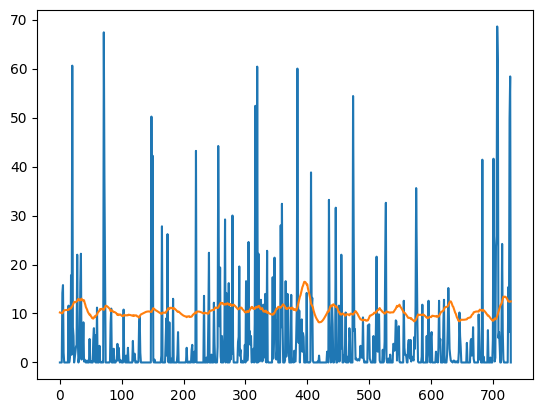

In [13]:
plt.plot(xls['precipitation'][0:730])
plt.plot(y)

In [8]:
y = dynamics.fit_in_sample([2.927e-02, 9.953, 0.998], xls['energia'])